In [1]:
from datasets import load_dataset_builder, load_dataset
import pandas as pd
import re


DATASET_NAME = "PrimeQA/clapnq_passages"

/home/joshuale/miniconda3/envs/local-rag/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Get basic info of the dataset and load it

In [2]:
ds_builder = load_dataset_builder(DATASET_NAME)
ds_builder.info.features

{'id': Value('string'), 'text': Value('string'), 'title': Value('string')}

In [3]:
dataset = load_dataset(DATASET_NAME, split="train")

In [4]:
dataset[0]

{'id': '827849752_115-357',
 'text': 'Egocentrism is the inability to differentiate between self and other . More specifically , it is the inability to untangle subjective schemas from objective reality ; an inability to understand or assume any perspective other than their own .',
 'title': 'Egocentrism'}

## 2. Convert to Pandas and combine passages to docs

In [5]:
df = dataset.to_pandas()
df.head(5)

,id,text,title
0,827849752_115-357,Egocentrism is the inability to differentiate ...,Egocentrism
1,827849752_358-743,Although egocentrism and narcissism appear sim...,Egocentrism
2,827849752_744-1186,Although egocentric behaviors are less promine...,Egocentrism
3,827849752_1187-1426,"Therefore , egocentrism is found across the li...",Egocentrism
4,827849752_1604-3189,The main concept infants and young children le...,Egocentrism


In [6]:
df["doc_id"] = df["id"].str.split("_").str[0]
df.head(5)

,id,text,title,doc_id
0,827849752_115-357,Egocentrism is the inability to differentiate ...,Egocentrism,827849752
1,827849752_358-743,Although egocentrism and narcissism appear sim...,Egocentrism,827849752
2,827849752_744-1186,Although egocentric behaviors are less promine...,Egocentrism,827849752
3,827849752_1187-1426,"Therefore , egocentrism is found across the li...",Egocentrism,827849752
4,827849752_1604-3189,The main concept infants and young children le...,Egocentrism,827849752


In [7]:
df_doc = df.groupby("doc_id", as_index=False).agg({"text": " ".join, "title": "first"})
df_doc.head(5)

,doc_id,text,title
0,382993645,WikiProject Birds ( hide ) ( Rated Category - ...,Category talk:Birds by common name
1,502521937,Entertainment desk < July 6 < < Jun July Aug >...,Wikipedia:Reference desk/Archives/Entertainmen...
2,618604858,"Tilted block faulting , also called rotational...",Tilted block faulting
3,682616029,( hide ) This article has multiple issues . Pl...,Purse distribution
4,683446452,This article does not cite any sources . Pleas...,Sugar Blues (song)


In [8]:
df_sample = df_doc[df_doc["title"].str.contains("Love the One You're With")]
sample_text = df_sample["text"].iloc[0]
sample_text

"`` Love the One You 're With '' Single by Stephen Stills from the album Stephen Stills B - side `` To a Flame '' Released November 1970 Format 7 - inch single Genre Folk rock Length 3 : 03 Label Atlantic Songwriter ( s ) Stephen Stills Producer ( s ) Stephen Stills Bill Halverson Stephen Stills singles chronology `` Love the One You 're With '' ( 1970 ) `` Sit Yourself Down '' ( 1971 ) `` Love the One You 're With '' ( 1970 ) `` Sit Yourself Down '' ( 1971 ) `` Love the One You 're With '' is a song by folk rocker Stephen Stills . It was released as the lead single from his debut self - titled studio album in November 1970 . The song , inspired by a remark Stills heard from musician Billy Preston , became his biggest hit single , peaking at No. 14 on the Billboard Hot 100 in early 1971 . David Crosby and Graham Nash , Stills ' fellow members of Crosby , Stills & Nash , provide background vocals on the song . The song was also covered by a number of artists , including The Isley Brothe

## 2. Helpers

In [10]:
import nltk

nltk.data.find('tokenizers/punkt')
nltk.download('punkt')
nltk.download('punkt_tab')


def clean_text(text: str) -> str:
    """
    Clean text by removing leading/trailing spaces and fixing common spacing issues.
    
    Args:
        text: Input text to clean
        
    Returns:
        Cleaned text with proper spacing
    """
    if not text:
        return text
    
    # Remove leading and trailing whitespace
    text = text.strip()
    
    # Remove extra spaces between words
    text = re.sub(r'\s+', ' ', text)
    
    # Fix spaces around punctuation
    # Remove spaces before commas, periods, semicolons, colons, exclamation marks, question marks
    text = re.sub(r'\s+([,.;:!?])', r'\1', text)
    
    # Remove spaces after opening brackets/parentheses
    text = re.sub(r'([(\[\{])\s+', r'\1', text)
    
    # Remove spaces before closing brackets/parentheses
    text = re.sub(r'\s+([)\]\}])', r'\1', text)
    
    # Add single space after punctuation if not already present (except at end of string)
    text = re.sub(r'([,.;:!?])(?=[^\s])', r'\1 ', text)
    
    # Fix spaces around quotes
    text = re.sub(r'\s*(["\'])\s*', r'\1', text)
    text = re.sub(r'(["\'])\s+', r'\1 ', text)
    text = re.sub(r'\s+(["\'])', r' \1', text)
    
    # Remove spaces around hyphens in compound words
    text = re.sub(r'\s*-\s*', '-', text)
    
    # Final cleanup of any remaining multiple spaces
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()


def nltk_sentence_split(text: str) -> list[str]:
    """
    Use NLTK's trained Punkt tokenizer for accurate sentence splitting.
    
    Args:
        text: Input text to split
        
    Returns:
        List of sentences
    """
    if not text.strip():
        return []
    
    sentences = nltk.sent_tokenize(text)
    return [sent.strip() for sent in sentences if sent.strip()]

def robust_sentence_split(text: str) -> list[str]:
    """
    Robust sentence splitter that handles abbreviations and edge cases better than NLTK.
    
    Args:
        text: Input text to split
        
    Returns:
        List of sentences
    """
    if not text.strip():
        return []
    
    # Extended list of common abbreviations that end with periods
    abbreviations = {
        # Titles
        'mr', 'mrs', 'ms', 'dr', 'prof', 'sr', 'jr', 'phd', 'md', 'esq',
        # Common abbreviations
        'vs', 'etc', 'inc', 'ltd', 'co', 'corp', 'dept', 'govt', 'org',
        # Numbers and references
        'no', 'nos', 'vol', 'pp', 'fig', 'figs', 'ch', 'sec', 'art',
        # Latin abbreviations
        'i.e', 'e.g', 'cf', 'ca', 'circa', 'et', 'al', 'ibid', 'op', 'cit',
        # Locations
        'st', 'ave', 'blvd', 'rd', 'dr', 'ln', 'ct', 'pl', 'sq',
        # Time
        'a.m', 'p.m', 'am', 'pm', 'jan', 'feb', 'mar', 'apr', 'jun', 'jul',
        'aug', 'sep', 'oct', 'nov', 'dec', 'mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun',
        # Other common ones
        'max', 'min', 'approx', 'est', 'ref', 'ed', 'eds', 'rev'
    }
    
    # First, protect known abbreviations by replacing periods temporarily
    protected_text = text
    
    # Pattern to match abbreviation + period + optional space + number/capital letter
    # This catches cases like "No. 14" or "Dr. Smith"
    for abbrev in abbreviations:
        # Case insensitive matching
        pattern = re.compile(rf'\b{re.escape(abbrev)}\.(?=\s*[A-Z0-9])', re.IGNORECASE)
        protected_text = pattern.sub(lambda m: m.group(0).replace('.', '§PERIOD§'), protected_text)
    
    # Also protect decimal numbers (e.g., "10.50")
    protected_text = re.sub(r'\b\d+\.\d+\b', lambda m: m.group(0).replace('.', '§PERIOD§'), protected_text)
    
    # Now split on sentence boundaries
    # Look for period, exclamation, or question mark followed by whitespace and capital letter
    sentences = re.split(r'(?<=[.!?])\s+(?=[A-Z])', protected_text)
    
    # Restore the protected periods
    sentences = [sent.replace('§PERIOD§', '.') for sent in sentences]
    
    # Clean up and filter empty sentences
    return [sent.strip() for sent in sentences if sent.strip()]


[nltk_data] Downloading package punkt to /home/joshuale/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/joshuale/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 3. Splitting by Sentences

### ii. Naive Splitting by "."

- a naive splitting without cleaning will result in many formatting errors, such as extra spaces before punctuation, etc.
- also "." does not always denote end of sentences, e.g., in abbreviations "No. 14". this causes sentences to be split incorrectly

In [ ]:
chunks = sample_text.split(".")
chunks = [chunk + "." for chunk in chunks if chunk.strip() != ""]
chunks[:5]

["`` Love the One You 're With '' Single by Stephen Stills from the album Stephen Stills B - side `` To a Flame '' Released November 1970 Format 7 - inch single Genre Folk rock Length 3 : 03 Label Atlantic Songwriter ( s ) Stephen Stills Producer ( s ) Stephen Stills Bill Halverson Stephen Stills singles chronology `` Love the One You 're With '' ( 1970 ) `` Sit Yourself Down '' ( 1971 ) `` Love the One You 're With '' ( 1970 ) `` Sit Yourself Down '' ( 1971 ) `` Love the One You 're With '' is a song by folk rocker Stephen Stills .",
 ' It was released as the lead single from his debut self - titled studio album in November 1970 .',
 ' The song , inspired by a remark Stills heard from musician Billy Preston , became his biggest hit single , peaking at No.',
 ' 14 on the Billboard Hot 100 in early 1971 .',
 " David Crosby and Graham Nash , Stills ' fellow members of Crosby , Stills & Nash , provide background vocals on the song ."]

In [64]:
cleaned_text = clean_text(sample_text)
chunks = cleaned_text.split(".")
chunks = [chunk + "." for chunk in chunks if chunk.strip() != ""]
chunks[:5]

["`` Love the One You're With''Single by Stephen Stills from the album Stephen Stills B-side `` To a Flame''Released November 1970 Format 7-inch single Genre Folk rock Length 3: 03 Label Atlantic Songwriter (s) Stephen Stills Producer (s) Stephen Stills Bill Halverson Stephen Stills singles chronology `` Love the One You're With''(1970) `` Sit Yourself Down''(1971) `` Love the One You're With''(1970) `` Sit Yourself Down''(1971) `` Love the One You're With''is a song by folk rocker Stephen Stills.",
 ' It was released as the lead single from his debut self-titled studio album in November 1970.',
 ' The song, inspired by a remark Stills heard from musician Billy Preston, became his biggest hit single, peaking at No.',
 ' 14 on the Billboard Hot 100 in early 1971.',
 " David Crosby and Graham Nash, Stills'fellow members of Crosby, Stills & Nash, provide background vocals on the song."]

### iii. Using Pre-trained Tokenizer from NLTK
- This method still cannot resolve the abbreviation

In [ ]:
cleaned_text = clean_text(sample_text)
chunks = nltk_sentence_split(cleaned_text)
chunks[:5]

["`` Love the One You're With''Single by Stephen Stills from the album Stephen Stills B-side `` To a Flame''Released November 1970 Format 7-inch single Genre Folk rock Length 3: 03 Label Atlantic Songwriter (s) Stephen Stills Producer (s) Stephen Stills Bill Halverson Stephen Stills singles chronology `` Love the One You're With''(1970) `` Sit Yourself Down''(1971) `` Love the One You're With''(1970) `` Sit Yourself Down''(1971) `` Love the One You're With''is a song by folk rocker Stephen Stills.",
 'It was released as the lead single from his debut self-titled studio album in November 1970.',
 'The song, inspired by a remark Stills heard from musician Billy Preston, became his biggest hit single, peaking at No.',
 '14 on the Billboard Hot 100 in early 1971.',
 "David Crosby and Graham Nash, Stills'fellow members of Crosby, Stills & Nash, provide background vocals on the song."]

### iv. Using Rule-based Sentence Splitter

In [61]:
chunks = robust_sentence_split(cleaned_text)
chunks[:5]

["`` Love the One You're With''Single by Stephen Stills from the album Stephen Stills B-side `` To a Flame''Released November 1970 Format 7-inch single Genre Folk rock Length 3: 03 Label Atlantic Songwriter (s) Stephen Stills Producer (s) Stephen Stills Bill Halverson Stephen Stills singles chronology `` Love the One You're With''(1970) `` Sit Yourself Down''(1971) `` Love the One You're With''(1970) `` Sit Yourself Down''(1971) `` Love the One You're With''is a song by folk rocker Stephen Stills.",
 'It was released as the lead single from his debut self-titled studio album in November 1970.',
 'The song, inspired by a remark Stills heard from musician Billy Preston, became his biggest hit single, peaking at No. 14 on the Billboard Hot 100 in early 1971.',
 "David Crosby and Graham Nash, Stills'fellow members of Crosby, Stills & Nash, provide background vocals on the song.",
 'The song was also covered by a number of artists, including The Isley Brothers, Bucks Fizz, and Luther Vandro

(array([5., 3., 8., 6., 4., 5., 1., 1., 2., 0., 1., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1.]),
 array([  1. ,   5.7,  10.4,  15.1,  19.8,  24.5,  29.2,  33.9,  38.6,
         43.3,  48. ,  52.7,  57.4,  62.1,  66.8,  71.5,  76.2,  80.9,
         85.6,  90.3,  95. ,  99.7, 104.4, 109.1, 113.8, 118.5, 123.2,
        127.9, 132.6, 137.3, 142. ]),
 <BarContainer object of 30 artists>)

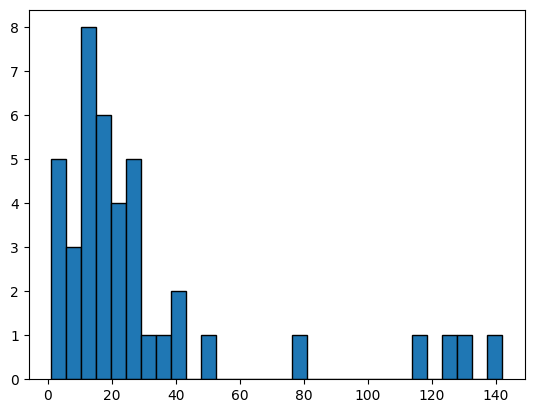

In [62]:
# plot distribution of sentence lengths in word count for robust_sentence_split:
import matplotlib.pyplot as plt
sentence_lengths = [len(chunk.split()) for chunk in chunks]
plt.hist(sentence_lengths, bins=30, edgecolor='black')

## 4. Recursive text splitter
- Demo of recursive text splitter from LangChain
- For actual implementation later, we will not use this method.
- Because the benchmark golden dataset is by sentences (though they are not cleaned), chunking by sentences will be more suitable to compare the retrieval performance with the golden datset.
- This method always need a chunk size, which cannot be fixed in this scenario as there is no fixed value.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [17]:
text_splitter = RecursiveCharacterTextSplitter(
    # separators=["\n\n", "\n", ".", " ", ""],
    separators=["."],
    chunk_size=500,
    chunk_overlap=0,
    # length_function=len,
    # is_separator_regex=False,
)

cleaned_text = clean_text(sample_text)
# texts = text_splitter.create_documents([sample_text])
chunks = text_splitter.split_text(cleaned_text)
chunks

["`` Love the One You're With''Single by Stephen Stills from the album Stephen Stills B-side `` To a Flame''Released November 1970 Format 7-inch single Genre Folk rock Length 3: 03 Label Atlantic Songwriter (s) Stephen Stills Producer (s) Stephen Stills Bill Halverson Stephen Stills singles chronology `` Love the One You're With''(1970) `` Sit Yourself Down''(1971) `` Love the One You're With''(1970) `` Sit Yourself Down''(1971) `` Love the One You're With''is a song by folk rocker Stephen Stills",
 ". It was released as the lead single from his debut self-titled studio album in November 1970. The song, inspired by a remark Stills heard from musician Billy Preston, became his biggest hit single, peaking at No. 14 on the Billboard Hot 100 in early 1971. David Crosby and Graham Nash, Stills'fellow members of Crosby, Stills & Nash, provide background vocals on the song. The song was also covered by a number of artists, including The Isley Brothers, Bucks Fizz, and Luther Vandross",
 ". St

In [ ]:
text_splitter = CharacterTextSplitter()


In [65]:
def word_count(text: str) -> int:
    return len(text.split())
# word_count(sample_text)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=50,
    chunk_overlap=5,
    length_function=word_count,
    is_separator_regex=False,
)
# texts = text_splitter.create_documents([sample_text])
chunks = text_splitter.split_text(sample_text)
chunks[0]

"`` Love the One You 're With '' Single by Stephen Stills from the album Stephen Stills B - side `` To a Flame '' Released November 1970 Format 7 - inch single Genre Folk rock Length 3 : 03 Label Atlantic Songwriter ( s ) Stephen Stills Producer ("